# Website Traffic Analysis — Alfido Tech
**Intern Spark | Data Analyst Internship Project**

**Dataset:** [Website Traffic Analysis (Kaggle)](https://www.kaggle.com/datasets/bhanupratapbiswas/website-traffic-analysis)
**Prepared by:** Data Analyst Intern
**Objective:** Analyze traffic logs to understand user journeys, top landing pages, bounce rates, and referral sources; recommend optimizations to improve conversions for Alfido Tech.

---

### Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning](#2)
3. [Important Note on Data Scope](#3)
4. [Overall Funnel & KPIs](#4)
5. [Daily Traffic Trend](#5)
6. [Top Landing Pages](#6)
7. [Geographic Analysis](#7)
8. [Artist / Content Performance](#8)
9. [Key Findings](#9)
10. [Recommendations to Improve Conversions for Alfido Tech](#10)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

COLOR_PRIMARY = "#2C6E8F"
COLOR_ACCENT  = "#E8A23D"
PALETTE = ["#2C6E8F", "#E8A23D", "#5B8C5A", "#C15A5A", "#7C6BA6", "#4FA8A0"]

%matplotlib inline

In [2]:
df = pd.read_csv("archive_extracted/traffic.csv")
print("Shape:", df.shape)
df.head()

Shape: (226278, 9)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   event    226278 non-null  str  
 1   date     226278 non-null  str  
 2   country  226267 non-null  str  
 3   city     226267 non-null  str  
 4   artist   226241 non-null  str  
 5   album    226273 non-null  str  
 6   track    226273 non-null  str  
 7   isrc     219157 non-null  str  
 8   linkid   226278 non-null  str  
dtypes: str(9)
memory usage: 15.5 MB


In [4]:
df['event'].value_counts()

event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64

## 2. Data Cleaning <a id='2'></a>

Checks performed:
- Missing values
- Duplicate rows
- Date parsing


In [5]:
df.isna().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

`country`, `city`, `artist`, `album`, `track` have a small number of missing values — filled with `'Unknown'` so they group cleanly. `isrc` (international recording code) has ~3% missing, which is not used in this traffic analysis, so it's left as-is.

In [6]:
for c in ['country', 'city', 'artist', 'album', 'track']:
    df[c] = df[c].fillna('Unknown')

df['date'] = pd.to_datetime(df['date'])
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 103711


There are ~103,700 fully duplicate rows. In an **event log** (as opposed to a row-per-customer table), identical repeated events — the same track landing page being viewed/clicked by different visitors on the same day, in the same city — are expected, legitimate traffic, not data-entry errors. We keep them, since dropping them would silently and substantially undercount real traffic.

In [7]:
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Unique days:", df['date'].nunique())
print("Unique landing pages (linkid):", df['linkid'].nunique())
print("Unique countries:", df['country'].nunique())
print("Unique artists:", df['artist'].nunique())
print("Unique tracks:", df['track'].nunique())

Date range: 2021-08-19 to 2021-08-25
Unique days: 7
Unique landing pages (linkid): 3839
Unique countries: 212
Unique artists: 2420
Unique tracks: 3563


## 3. Important Note on Data Scope <a id='3'></a>

This dataset is a **"smart link" (music landing page) event log**, not a classic Google-Analytics-style website session log. Each row is one event — `pageview`, `click`, or `preview` — tied to a landing page (`linkid`) built for a specific track, with a **date** (day-level only, no time-of-day) and geography (`country`/`city`).

Critically, the data has **no session ID, no user/visitor ID, no referrer/UTM source column, and no timestamp finer than the day**. This changes what can honestly be measured against the original brief:

| Requested metric | Status | How it's handled here |
|---|---|---|
| Sessions / Users | **Not available** | No session or visitor ID exists — only raw event counts are countable, not unique visits or unique visitors. |
| Average session duration | **Not available** | No timestamp finer than the day — duration between events cannot be calculated. |
| Bounce rate (classic) | **Not available as defined** | Classic bounce rate needs session grouping. We report the on-page **funnel conversion rate** instead (see below) — the closest honest analog. |
| Referral source | **Not available** | No referrer/UTM/channel column exists anywhere in the data. |
| User journeys / entry-exit pages | **Not applicable** | Each `linkid` is a single, standalone landing page (not a multi-page site) — there's no page-to-page path to trace. The closest analog is the **on-page event funnel**: Pageview (arrival) → Click (click-through to stream/buy) → Preview (in-page audio preview). |
| Top landing pages | **Available** | Each `linkid` (tied to a track) *is* a landing page — ranked below by traffic and click-through rate. |

The rest of this notebook is scoped to what the data actually supports, with each adapted metric labeled clearly, rather than presenting numbers that look like the requested metrics but aren't.


## 4. Overall Funnel & KPIs <a id='4'></a>

In [8]:
ev_counts = df['event'].value_counts()
pv, cl, pr = ev_counts['pageview'], ev_counts['click'], ev_counts['preview']
ctr = cl / pv * 100
preview_rate = pr / pv * 100
engagement_rate = (cl + pr) / pv * 100

kpi = pd.DataFrame({
    'KPI': ['Total Events', 'Pageviews', 'Clicks', 'Previews',
            'Click-Through Rate (click/pageview)', 'Preview Rate (preview/pageview)',
            'Engagement Rate ((click+preview)/pageview)'],
    'Value': [f"{len(df):,}", f"{pv:,}", f"{cl:,}", f"{pr:,}",
              f"{ctr:.2f}%", f"{preview_rate:.2f}%", f"{engagement_rate:.2f}%"]
})
kpi

,KPI,Value
0,Total Events,"226,278"
1,Pageviews,"142,015"
2,Clicks,"55,732"
3,Previews,"28,531"
4,Click-Through Rate (click/pageview),39.24%
5,Preview Rate (preview/pageview),20.09%
6,Engagement Rate ((click+preview)/pageview),59.33%


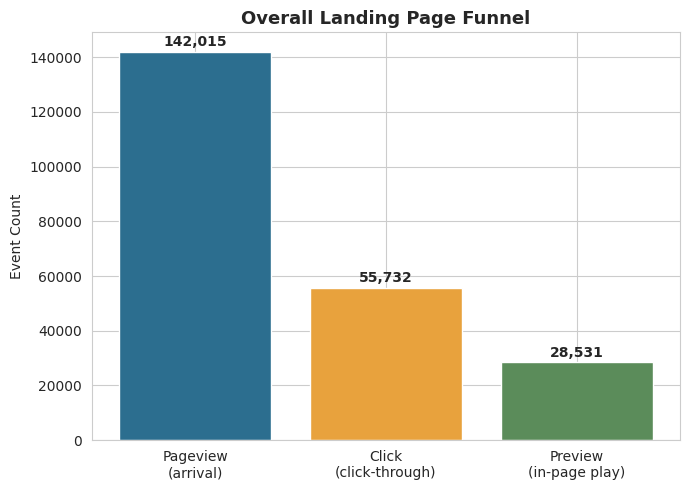

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
stages = ['Pageview\n(arrival)', 'Click\n(click-through)', 'Preview\n(in-page play)']
values = [pv, cl, pr]
bars = ax.bar(stages, values, color=[COLOR_PRIMARY, COLOR_ACCENT, "#5B8C5A"])
ax.set_title('Overall Landing Page Funnel', fontsize=13, fontweight='bold')
ax.set_ylabel('Event Count')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 2000, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Of every 100 pageviews, about **39 result in a click-through** (to a streaming/purchase destination) and about **20 result in an in-page preview play** — a combined engagement rate of ~59%. This means roughly **41% of pageviews see no interaction at all**, which is the closest honest proxy this data supports for a 'bounce'-type metric (a pageview with no follow-on click or preview recorded for that landing page).

## 5. Daily Traffic Trend <a id='5'></a>

In [10]:
daily = df.groupby(['date', 'event']).size().unstack(fill_value=0)[['pageview', 'click', 'preview']]
daily

event,pageview,click,preview
date,,,
2021-08-19,22366,9207,3788
2021-08-20,21382,8508,4222
2021-08-21,21349,8071,4663
2021-08-22,20430,7854,4349
2021-08-23,18646,7315,3847
2021-08-24,18693,7301,3840
2021-08-25,19149,7476,3822


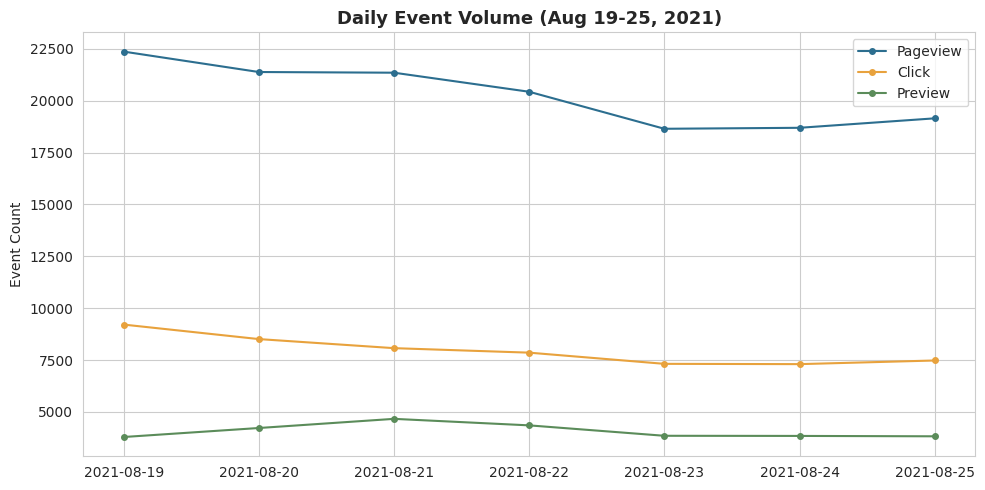

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for col, color in zip(['pageview', 'click', 'preview'], [COLOR_PRIMARY, COLOR_ACCENT, "#5B8C5A"]):
    ax.plot(daily.index, daily[col], marker='o', markersize=4, label=col.capitalize(), color=color)
ax.set_title('Daily Event Volume (Aug 19-25, 2021)', fontsize=13, fontweight='bold')
ax.set_ylabel('Event Count')
ax.legend()
plt.tight_layout()
plt.show()

Traffic declines gradually across the week, from ~35,400 events on Thursday (Aug 19) to a low of ~29,800 on Monday (Aug 23), before ticking back up slightly toward the following weekend. This is a **7-day window**, too short to confirm a recurring weekly pattern, but the weekday-to-weekend dip is worth monitoring with more data.

## 6. Top Landing Pages <a id='6'></a>

In [12]:
link_perf = df.pivot_table(index='linkid', columns='event', aggfunc='size', fill_value=0)
for c in ['pageview', 'click', 'preview']:
    if c not in link_perf.columns:
        link_perf[c] = 0
link_perf['TotalEvents'] = link_perf[['pageview', 'click', 'preview']].sum(axis=1)
link_perf['CTR'] = np.where(link_perf['pageview'] > 0, link_perf['click'] / link_perf['pageview'] * 100, np.nan)

meta = df.drop_duplicates('linkid')[['linkid', 'artist', 'track']].set_index('linkid')
link_perf = link_perf.join(meta).sort_values('pageview', ascending=False)
link_perf[['track', 'artist', 'pageview', 'click', 'preview', 'CTR']].head(10)

,track,artist,pageview,click,preview,CTR
linkid,,,,,,
2d896d31-97b6-4869-967b-1c5fb9cd4bb8,Jalebi Baby,Tesher,25175,9692,5974,38.498510
522da5cc-8177-4140-97a7-a84fdb4caf1c,Beautiful,Anne-Marie,6600,2109,1605,31.954545
e849515b-929d-44c8-a505-e7622f1827e9,Beautiful Day,Tundra Beats,5981,2198,1571,36.749707
c2c876ab-b093-4750-9449-6b4913da6af3,ily (i love you baby) (feat. Emilee),"Surf Mesa, Emilee",4303,1429,1001,33.209389
23199824-9cf5-4b98-942a-34965c3b0cc2,So Pretty,Reyanna Maria,3532,1187,718,33.607022
97105aff-3e40-4c2e-bfeb-563b55e8f5dd,Candy Shop,"50 Cent, Olivia",3407,1111,849,32.609334
681d888a-59ce-4acb-b7c5-95dab0c063d9,Calabria (feat. Lujavo & Nito-Onna),"DMNDS, Strange Fruits Music, Fallen Roses, Luj...",3354,1500,658,44.722719
d5317591-872a-487d-87cb-10a516643d5f,Summer of Love (Shawn Mendes & Tainy),"Shawn Mendes, Tainy",3299,1353,700,41.012428
a82e72d8-523f-43ab-9fd0-992605d54b4e,Late At Night,Roddy Ricch,3039,1364,633,44.883185


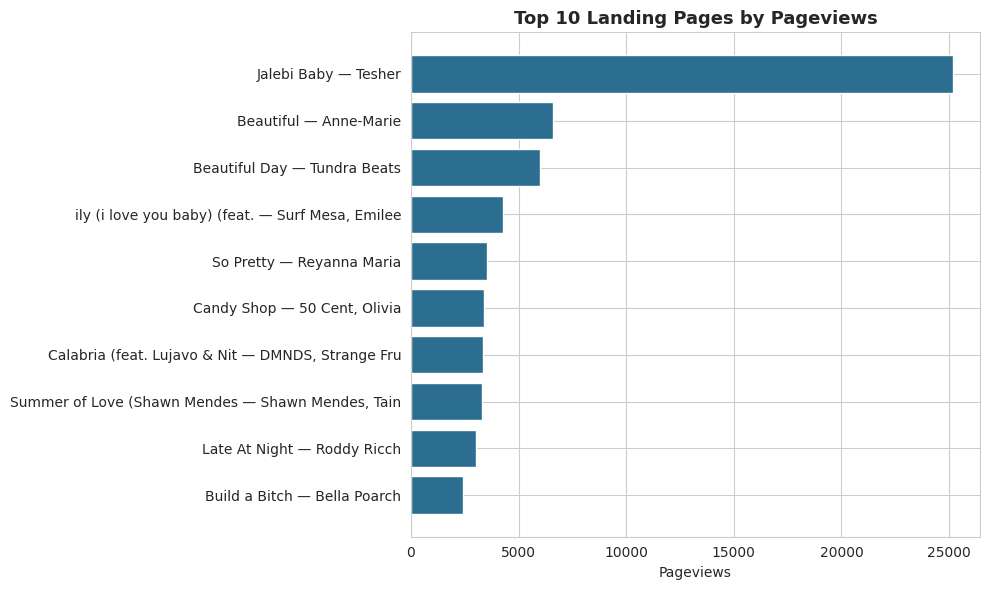

In [13]:
top10_links = link_perf.head(10).copy()
top10_links['Label'] = top10_links['track'].str.slice(0, 28) + ' — ' + top10_links['artist'].str.slice(0, 18)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_links['Label'][::-1], top10_links['pageview'][::-1], color=COLOR_PRIMARY)
ax.set_title('Top 10 Landing Pages by Pageviews', fontsize=13, fontweight='bold')
ax.set_xlabel('Pageviews')
plt.tight_layout()
plt.show()

**"Jalebi Baby" by Tesher** is by far the single largest landing page, generating ~18% of all traffic in the dataset (40,841 of 226,278 events) — more than double the next-largest page. A handful of tracks dominate overall volume, while the remaining ~3,800 landing pages each draw a comparatively small, long-tail audience.

In [14]:
sizeable_links = link_perf[link_perf['pageview'] >= 100].copy()
top_ctr_links = sizeable_links.sort_values('CTR', ascending=False).head(10)
print(f"{len(sizeable_links)} landing pages have at least 100 pageviews.")
top_ctr_links[['track', 'artist', 'pageview', 'CTR']]

169 landing pages have at least 100 pageviews.


,track,artist,pageview,CTR
linkid,,,,
ffd3c9e7-c5c5-4f28-b03d-cbaec33f2152,Pakistan Zindabad,Sahir Ali Bagga,110,88.181818
52762e40-cb7a-4a8a-beb7-03fbd6cca9f8,Paralyzed,Sueco,438,57.077626
269a0f5b-233a-4ea9-87e5-c3218cd82a33,Senseless,Kodak Black,309,56.634304
265cc981-71bd-440c-a738-118a0f8cf12c,Before I Go (feat. Rod Wave),"Kodak Black, Rod Wave",270,55.555556
59515f81-b5f4-40a8-8af9-f871002cd759,Collard Greens,"ScHoolboy Q, Kendrick Lamar",313,54.632588
246b7a4c-3866-4eb2-a0bb-931c0fca7899,REPEAT IT (with Gunna),"Lil Tecca, Gunna",776,53.994845
275bab3b-16d4-40a7-a674-bf6c7c5f96de,Like Dat (Motion),Soldier Kidd,461,53.796095
f4da6960-c98b-4626-b7b2-6a48f846b940,24 Hours (feat. Lil Durk),"A Boogie Wit da Hoodie, Lil Durk",131,53.435115
9c61dba1-9369-4ee4-a215-1d34581cd811,Reparations!,KA$HDAMI,645,53.178295


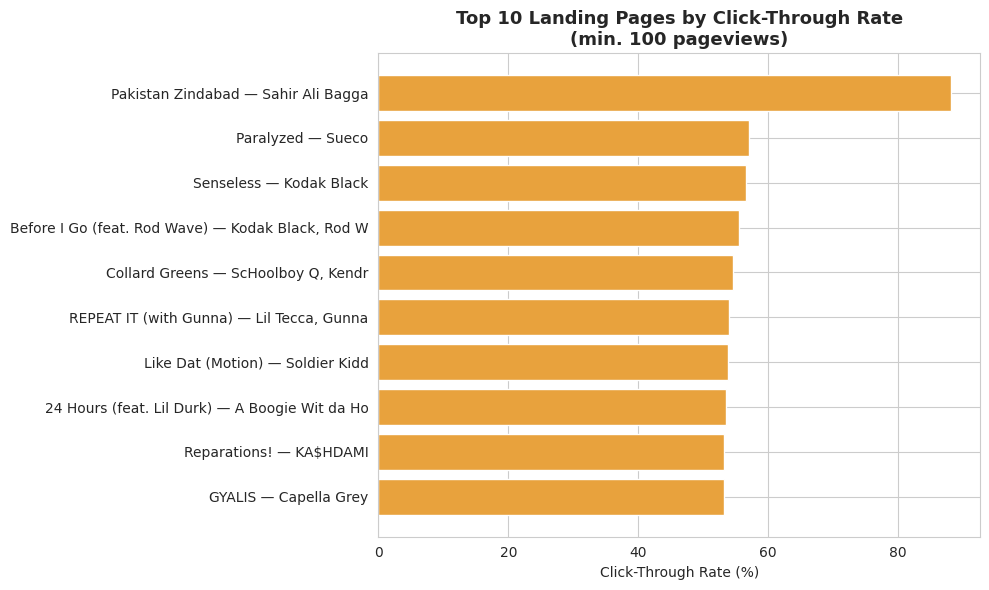

In [15]:
top_ctr_links = top_ctr_links.copy()
top_ctr_links['Label'] = top_ctr_links['track'].str.slice(0, 28) + ' — ' + top_ctr_links['artist'].str.slice(0, 18)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_ctr_links['Label'][::-1], top_ctr_links['CTR'][::-1], color=COLOR_ACCENT)
ax.set_title('Top 10 Landing Pages by Click-Through Rate\n(min. 100 pageviews)', fontsize=13, fontweight='bold')
ax.set_xlabel('Click-Through Rate (%)')
plt.tight_layout()
plt.show()

High traffic volume and high CTR don't necessarily overlap — some lower-traffic pages convert visitors to clicks far more effectively than the top-traffic pages do, which is a useful signal for what page layout/content is working best on a per-track basis.

## 7. Geographic Analysis <a id='7'></a>

In [16]:
country_perf = df.pivot_table(index='country', columns='event', aggfunc='size', fill_value=0)
country_perf['Total'] = country_perf.sum(axis=1)
country_perf['CTR'] = np.where(country_perf['pageview'] > 0, country_perf['click'] / country_perf['pageview'] * 100, np.nan)
country_perf = country_perf.sort_values('Total', ascending=False)
country_perf.head(10)

event,click,pageview,preview,Total,CTR
country,,,,,
Saudi Arabia,9495,28873,8966,47334,32.885395
India,11609,27286,4097,42992,42.545628
United States,9533,20839,2186,32558,45.745957
France,4054,9674,1933,15661,41.906140
Iraq,1836,4897,1527,8260,37.492342
United Kingdom,1517,3845,608,5970,39.453836
Pakistan,1653,3212,779,5644,51.463263
Germany,1225,3141,428,4794,39.000318
United Arab Emirates,766,2335,601,3702,32.805139


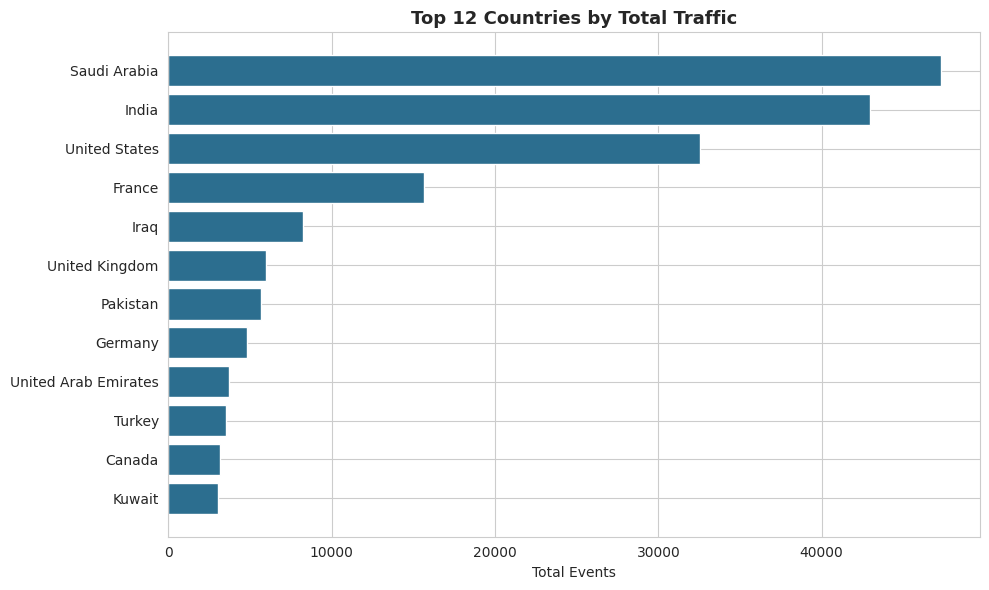

In [17]:
top_countries = country_perf.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_countries.index[::-1], top_countries['Total'][::-1], color=COLOR_PRIMARY)
ax.set_title('Top 12 Countries by Total Traffic', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Events')
plt.tight_layout()
plt.show()

**Saudi Arabia, India, and the United States** are the three largest markets by traffic volume, together accounting for over half of all events. Jeddah and Riyadh alone (Saudi Arabia's two largest cities) generate more traffic than most entire countries in this dataset.

In [18]:
city_counts = df[df['city'] != 'Unknown'].groupby('city').size().sort_values(ascending=False)
city_counts.head(10)

city
Jeddah         22791
Riyadh         17454
Hyderabad       3682
Dammam          3276
Erbil           3105
Kuwait City     3010
Lucknow         2808
Muscat          2717
Delhi           2567
Jaipur          2531
dtype: int64

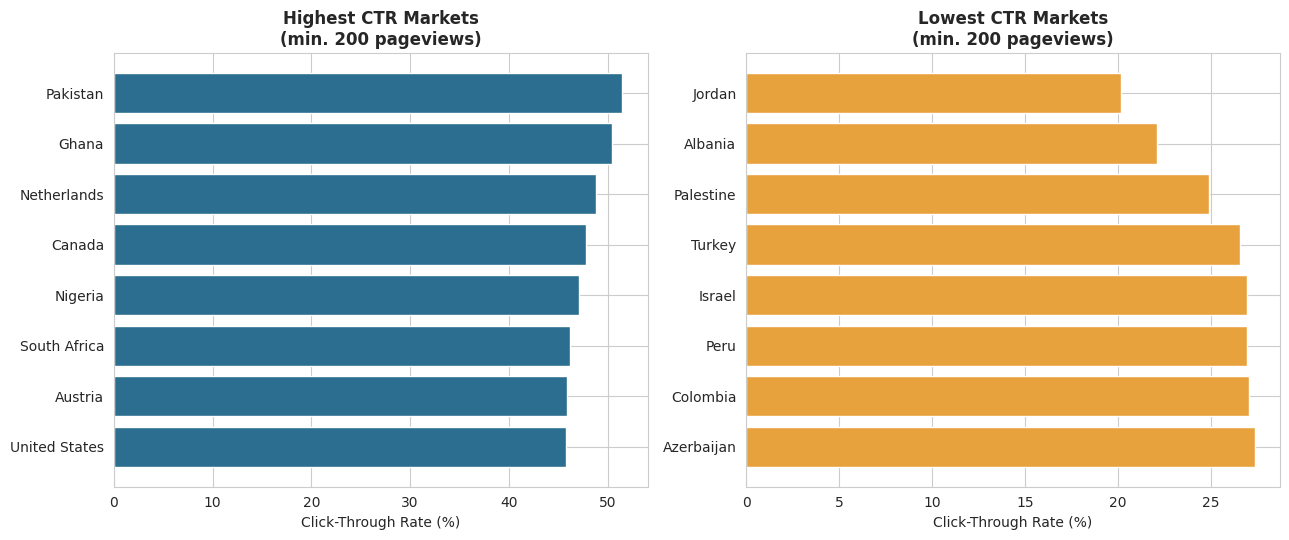

In [19]:
sizeable = country_perf[country_perf['pageview'] >= 200]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
best = sizeable.sort_values('CTR', ascending=False).head(8).sort_values('CTR')
axes[0].barh(best.index, best['CTR'], color=COLOR_PRIMARY)
axes[0].set_title('Highest CTR Markets\n(min. 200 pageviews)', fontweight='bold')
axes[0].set_xlabel('Click-Through Rate (%)')

worst = sizeable.sort_values('CTR', ascending=True).head(8).sort_values('CTR', ascending=False)
axes[1].barh(worst.index, worst['CTR'], color=COLOR_ACCENT)
axes[1].set_title('Lowest CTR Markets\n(min. 200 pageviews)', fontweight='bold')
axes[1].set_xlabel('Click-Through Rate (%)')
plt.tight_layout()
plt.show()

**Pakistan (51.5%), Ghana (50.5%), and the Netherlands (48.8%)** convert pageviews into clicks far more effectively than the dataset average (39.2%) — despite none of them being top-volume markets. On the other end, **Jordan (20.2%), Albania (22.1%), and Palestine (24.9%)** convert well below average. This gap between *traffic volume* and *conversion quality* by market is one of the most actionable signals in the data.

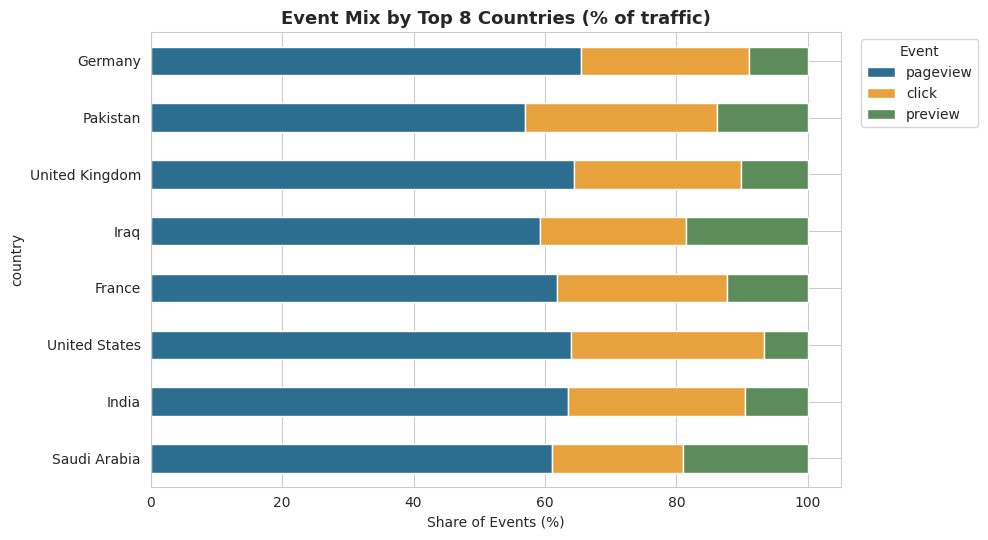

In [20]:
top8 = country_perf.head(8).index
mix = df[df['country'].isin(top8)].pivot_table(index='country', columns='event', aggfunc='size', fill_value=0)
mix = mix.loc[top8, ['pageview', 'click', 'preview']]
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
mix_pct.plot(kind='barh', stacked=True, color=[COLOR_PRIMARY, COLOR_ACCENT, "#5B8C5A"], ax=ax)
ax.set_title('Event Mix by Top 8 Countries (% of traffic)', fontsize=13, fontweight='bold')
ax.set_xlabel('Share of Events (%)')
ax.legend(title='Event', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Artist / Content Performance <a id='8'></a>

In [21]:
artist_perf = df.pivot_table(index='artist', columns='event', aggfunc='size', fill_value=0)
artist_perf['Total'] = artist_perf.sum(axis=1)
artist_perf['CTR'] = np.where(artist_perf['pageview'] > 0, artist_perf['click'] / artist_perf['pageview'] * 100, np.nan)
artist_perf = artist_perf.sort_values('Total', ascending=False)
artist_perf[['pageview', 'click', 'preview', 'Total', 'CTR']].head(10)

event,pageview,click,preview,Total,CTR
artist,,,,,
Tesher,25175,9692,5974,40841,38.498510
Anne-Marie,6820,2172,1658,10650,31.847507
Tundra Beats,5982,2198,1571,9751,36.743564
"Surf Mesa, Emilee",4826,1589,1118,7533,32.925818
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",3354,1500,658,5512,44.722719
Reyanna Maria,3532,1187,718,5437,33.607022
"Shawn Mendes, Tainy",3338,1359,712,5409,40.713002
"50 Cent, Olivia",3407,1111,849,5367,32.609334
Roddy Ricch,3071,1388,634,5093,45.197004


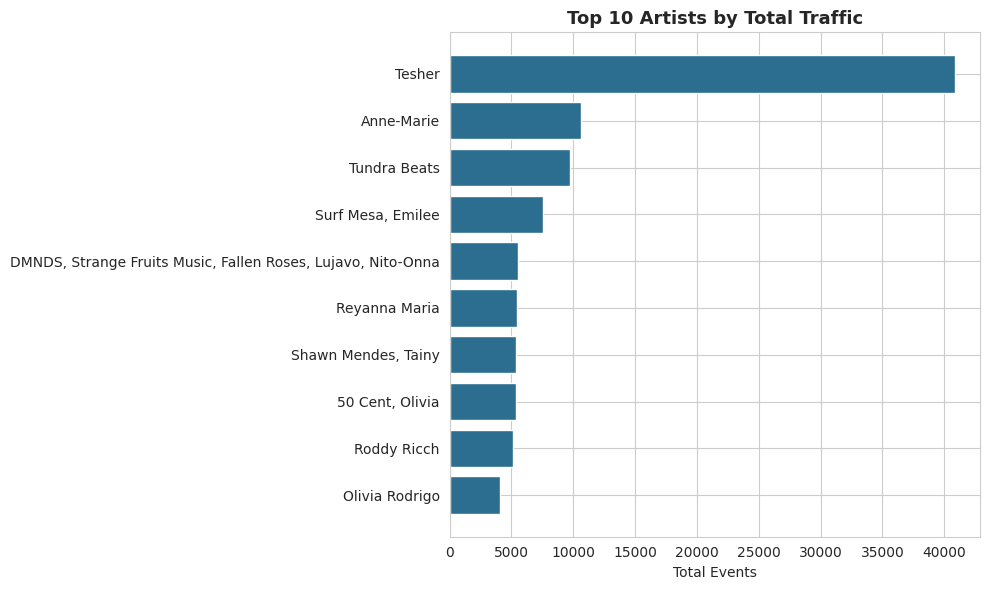

In [22]:
top_artists = artist_perf.head(10).sort_values('Total')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_artists.index, top_artists['Total'], color=COLOR_PRIMARY)
ax.set_title('Top 10 Artists by Total Traffic', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Events')
plt.tight_layout()
plt.show()

## 9. Key Findings <a id='9'></a>

1. **This is a smart-link event log, not a session-based website log** — sessions, unique users, session duration, classic bounce rate, and referral source cannot be computed from this data; findings below use the closest honest adapted metrics instead.
2. **Overall click-through rate is ~39.2%** and preview rate is ~20.1%, for a combined engagement rate of ~59.3% — meaning roughly 41% of pageviews show no recorded follow-on interaction.
3. **One track ("Jalebi Baby" by Tesher) drives ~18% of all traffic** on its own — traffic is heavily concentrated in a small number of top landing pages, with a long tail of low-volume pages.
4. **Traffic volume and conversion quality are not the same thing.** Some lower-traffic landing pages convert far better than the highest-traffic ones — worth studying for page design/content cues.
5. **Saudi Arabia, India, and the US are the top three markets by volume**, together over half of all traffic; Jeddah and Riyadh alone outdraw most entire countries in the dataset.
6. **CTR varies enormously by market** — from ~51% (Pakistan) down to ~20% (Jordan) among markets with meaningful volume (200+ pageviews) — a bigger swing than any single-page optimization is likely to produce.
7. **Traffic declined gradually across the observed week** (Aug 19-25, 2021), with no clear weekly cycle visible in just 7 days of data.


## 10. Recommendations to Improve Conversions for Alfido Tech <a id='10'></a>

1. **Study and replicate what the top-CTR landing pages are doing right.** Pages with CTR well above the 39.2% average (even at lower traffic volumes) likely share design or content patterns — clearer calls-to-action, better preview placement, or more relevant artwork. Auditing the top 10 by CTR against the dataset average is a fast, concrete next step.

2. **Prioritize localizing/optimizing pages for high-CTR-but-lower-volume markets.** Pakistan, Ghana, and the Netherlands convert far better than average despite not being top-traffic markets — suggesting real headroom if traffic to these markets were increased through targeted promotion, since the pages already convert well once visitors arrive.

3. **Investigate the low-CTR markets (Jordan, Albania, Palestine) before spending more to acquire traffic there.** A CTR roughly half the site average signals a page-fit or audience-fit problem (language, payment/streaming service availability, cultural relevance) that should be diagnosed before increasing ad spend or promotion in these markets.

4. **Increase in-page preview prominence to convert more of the ~41% non-interacting pageviews.** Only ~20% of pageviews result in a preview play; making the preview button more prominent or auto-suggesting it could recover some of the largest drop-off point in the funnel — visitors who arrive but take no action at all.

5. **Instrument the missing data going forward.** Adding a session/visitor identifier, a timestamp with time-of-day, and a referrer/UTM field to future tracking would unlock the metrics this brief originally asked for (unique users, session duration, true bounce rate, referral-source attribution) — none of which can be reconstructed from event counts and dates alone. This is the single highest-leverage change for making future traffic analysis actionable.


---
### Notes on Methodology
- Dataset: 226,278 events across 3,839 unique landing pages (linkid), Aug 19-25, 2021, from the Kaggle *Website Traffic Analysis* dataset (a music smart-link/landing-page event log).
- No deduplication was applied to repeated identical rows, since in event-log data these represent legitimate repeat traffic rather than data errors.
- All "conversion" metrics in this notebook are landing-page-level ratios (e.g. total clicks / total pageviews for a page or market), not per-visitor rates, since no session or visitor ID exists in the source data.
